In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score, roc_auc_score



In [3]:
train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')

train.shape, test.shape

((18359, 14), (15021, 13))

In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18359 entries, 0 to 18358
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             18359 non-null  int64  
 1   city                    18359 non-null  object 
 2   city_development_index  18359 non-null  float64
 3   gender                  14261 non-null  object 
 4   relevent_experience     18359 non-null  object 
 5   enrolled_university     18017 non-null  object 
 6   education_level         17902 non-null  object 
 7   major_discipline        15521 non-null  object 
 8   experience              18300 non-null  object 
 9   company_size            13580 non-null  object 
 10  company_type            13320 non-null  object 
 11  last_new_job            17992 non-null  object 
 12  training_hours          18359 non-null  int64  
 13  target                  18359 non-null  int64  
dtypes: float64(1), int64(3), object(10)
me

In [5]:
train.head(3)

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,23798,city_149,0.689,Male,Has relevent experience,no_enrollment,Graduate,STEM,3,100-500,Pvt Ltd,1,106,0
1,29166,city_83,0.923,Male,Has relevent experience,no_enrollment,Graduate,STEM,14,<10,Funded Startup,1,69,0
2,46,city_16,0.910,NaN,Has relevent experience,no_enrollment,Graduate,STEM,6,50-99,Public Sector,2,4,0


In [6]:
# na cols 
na_cols = train.columns[train.isna().any()]
na_cols

Index(['gender', 'enrolled_university', 'education_level', 'major_discipline',
       'experience', 'company_size', 'company_type', 'last_new_job'],
      dtype='object')

In [7]:
# no of missing cells in na cols
train.isna().sum()[train.isna().sum() > 0]

gender                 4098
enrolled_university     342
education_level         457
major_discipline       2838
experience               59
company_size           4779
company_type           5039
last_new_job            367
dtype: int64

In [8]:
# missing cell % in each col
train.isna().mean()[train.isna().mean()>0]

gender                 0.223215
enrolled_university    0.018628
education_level        0.024892
major_discipline       0.154584
experience             0.003214
company_size           0.260308
company_type           0.274470
last_new_job           0.019990
dtype: float64

In [9]:
train[na_cols].isna().sum()/train.shape[0]*100

gender                 22.321477
enrolled_university     1.862847
education_level         2.489242
major_discipline       15.458358
experience              0.321368
company_size           26.030830
company_type           27.447029
last_new_job            1.999020
dtype: float64

In [10]:
train['target'].value_counts()

target
0    15934
1     2425
Name: count, dtype: int64

<Axes: xlabel='target'>

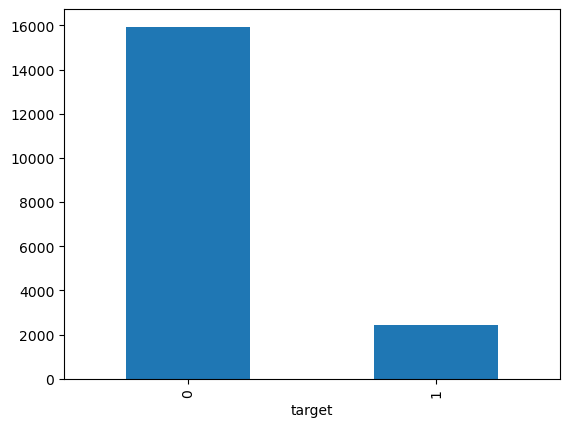

In [11]:
tgt_col = ['target']
ign_cols = ['enrollee_id']
train['target'].value_counts().plot(kind ='bar')

In [12]:
#listing unique values for all cols
for col in train.drop(columns = ign_cols).columns:
    print(f'{col} : {train[col].unique()}')

city : ['city_149' 'city_83' 'city_16' 'city_64' 'city_100' 'city_21' 'city_114'
 'city_103' 'city_97' 'city_160' 'city_65' 'city_90' 'city_75' 'city_136'
 'city_159' 'city_67' 'city_28' 'city_10' 'city_73' 'city_76' 'city_104'
 'city_27' 'city_30' 'city_61' 'city_99' 'city_41' 'city_142' 'city_9'
 'city_116' 'city_128' 'city_74' 'city_69' 'city_1' 'city_176' 'city_40'
 'city_123' 'city_152' 'city_165' 'city_89' 'city_36' 'city_44' 'city_46'
 'city_45' 'city_134' 'city_93' 'city_180' 'city_162' 'city_84' 'city_138'
 'city_173' 'city_19' 'city_71' 'city_158' 'city_23' 'city_102' 'city_105'
 'city_91' 'city_11' 'city_13' 'city_57' 'city_20' 'city_14' 'city_37'
 'city_115' 'city_50' 'city_167' 'city_12' 'city_143' 'city_126' 'city_77'
 'city_101' 'city_150' 'city_179' 'city_107' 'city_175' 'city_146'
 'city_98' 'city_166' 'city_118' 'city_129' 'city_127' 'city_24' 'city_81'
 'city_26' 'city_139' 'city_94' 'city_70' 'city_145' 'city_157' 'city_111'
 'city_78' 'city_80' 'city_33' 'city_7' '

<Axes: xlabel='training_hours', ylabel='Density'>

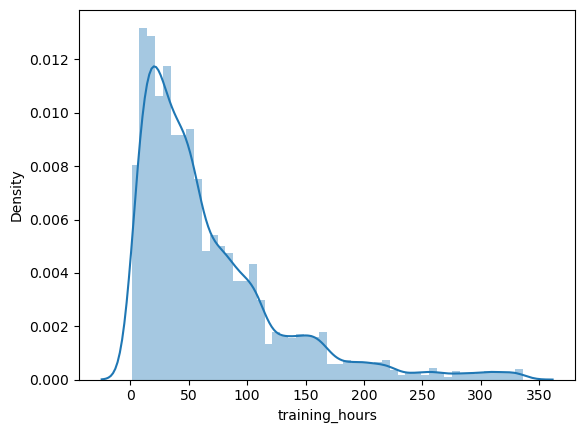

In [13]:
sns.distplot(train['training_hours'])

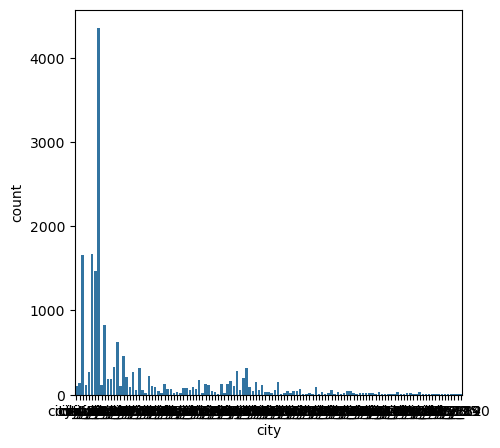

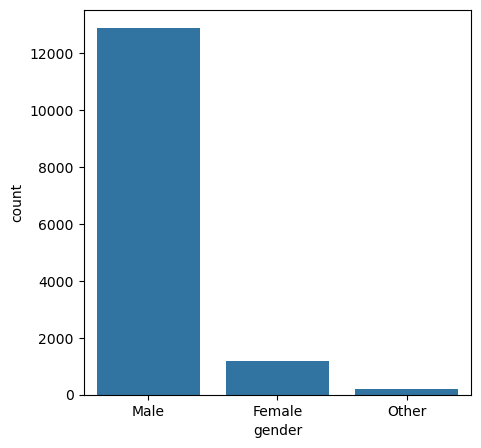

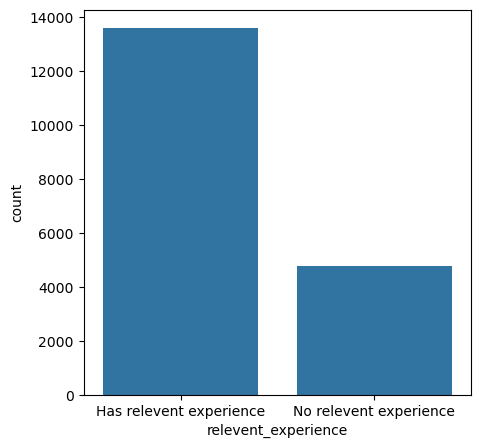

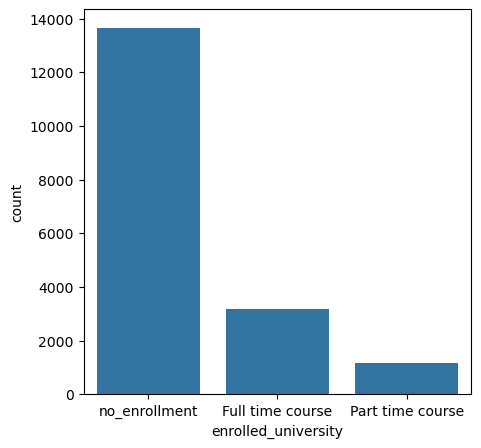

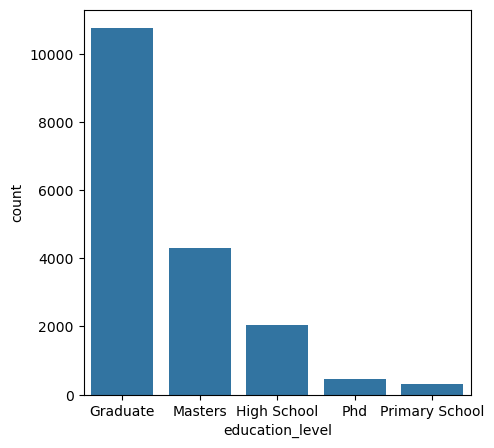

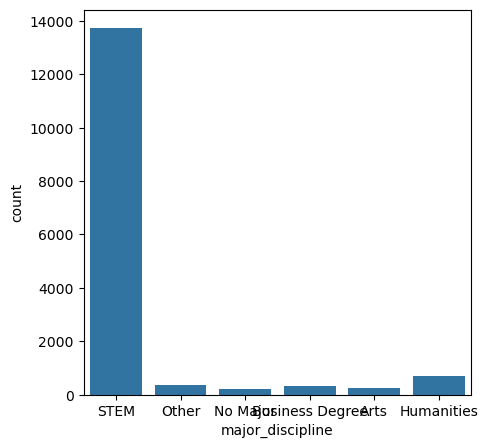

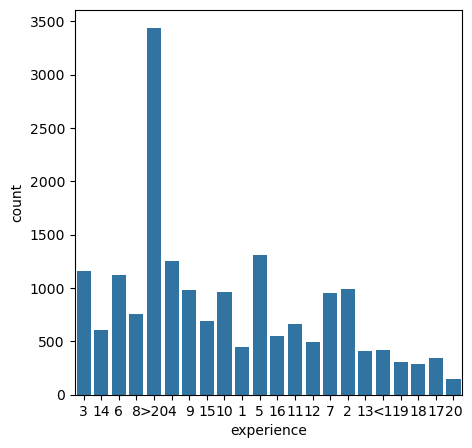

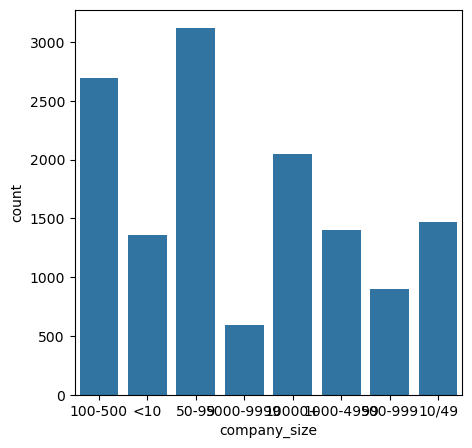

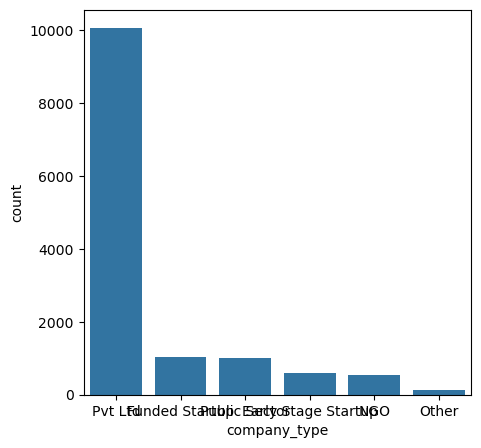

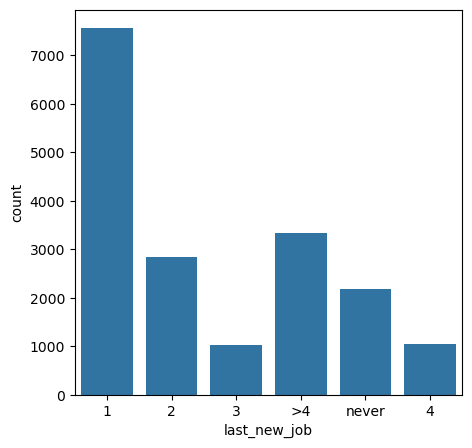

In [14]:
for col in train.select_dtypes(include = 'object').columns:
    plt.figure(figsize =(5,5))
    sns.countplot (data = train, x=col)
    plt.show()

In [15]:
cat_cols = train.select_dtypes(exclude = np.number).columns
num_cols = train.drop(columns = ign_cols + tgt_col).select_dtypes(include = np.number).columns

tgt_col,ign_cols, cat_cols, num_cols

(['target'],
 ['enrollee_id'],
 Index(['city', 'gender', 'relevent_experience', 'enrolled_university',
        'education_level', 'major_discipline', 'experience', 'company_size',
        'company_type', 'last_new_job'],
       dtype='object'),
 Index(['city_development_index', 'training_hours'], dtype='object'))

In [16]:
# Category Transformer pipe

cat_transformer = Pipeline( steps =[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown = 'ignore'))
])

# Numeric Transformer Pipe

num_transformer = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy = 'median')),
    ('scaler', StandardScaler())
])

cat_transformer, num_transformer

(Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                 ('ohe', OneHotEncoder(handle_unknown='ignore'))]),
 Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                 ('scaler', StandardScaler())]))

In [17]:
preprocess = ColumnTransformer(transformers =[
    ('cat_transform', cat_transformer, cat_cols),
    ('num_transform', num_transformer, num_cols)
])

In [18]:
model_pipeline = Pipeline(steps = [
    ('preprocess', preprocess),
    ('model', LogisticRegression())
])

In [19]:
X = train.drop(columns = tgt_col + ign_cols)
y = train[tgt_col]

train_X, test_X, train_y, test_y = train_test_split(X,y,test_size = 0.1, random_state = 42)
train_X.shape, test_X.shape, train_y.shape, test_y.shape 

((16523, 12), (1836, 12), (16523, 1), (1836, 1))

In [20]:
model_pipeline.fit(train_X,train_y)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat_transform', ...), ('num_transform', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [21]:
model_pipeline.predict(test_X)

array([0, 0, 0, ..., 0, 0, 0], shape=(1836,))

In [22]:
model_pipeline.predict_proba(test_X)

array([[0.83788855, 0.16211145],
       [0.89245315, 0.10754685],
       [0.9161205 , 0.0838795 ],
       ...,
       [0.88705445, 0.11294555],
       [0.92663684, 0.07336316],
       [0.91339528, 0.08660472]], shape=(1836, 2))

In [23]:
def model_train_cal_eval(train_X, train_y, test_X, test_y, model_pipeline):
  predicted_train_tgt = model_pipeline.predict(train_X)
  predicted_test_tgt = model_pipeline.predict(test_X)

  print('Train Score:',roc_auc_score(train_y, predicted_train_tgt))
  print('Test Score:',roc_auc_score(test_y, predicted_test_tgt))

In [24]:
model_train_cal_eval(train_X, train_y, test_X, test_y, model_pipeline)

Train Score: 0.5019305346679436
Test Score: 0.50199203187251


In [25]:
sub = pd.read_csv('sample_submission.csv')

In [26]:
sub['target'] = model_pipeline.predict_proba(test.drop(columns=ign_cols))

In [27]:
sub['target']

0        0.326227
1        0.895432
2        0.749377
3        0.912593
4        0.951221
           ...   
15016    0.871902
15017    0.738892
15018    0.934935
15019    0.791640
15020    0.646199
Name: target, Length: 15021, dtype: float64

In [28]:
sub['target'] = model_pipeline.predict_proba(test.drop(columns=ign_cols))[:,1]
sub['target']

0        0.673773
1        0.104568
2        0.250623
3        0.087407
4        0.048779
           ...   
15016    0.128098
15017    0.261108
15018    0.065065
15019    0.208360
15020    0.353801
Name: target, Length: 15021, dtype: float64

In [29]:
sub

,enrollee_id,target
0,16548,0.673773
1,12036,0.104568
2,11061,0.250623
3,5032,0.087407
4,17599,0.048779
...,...,...
15016,11308,0.128098
15017,14612,0.261108
15018,33346,0.065065
15019,14506,0.208360


In [30]:
sub.to_csv('sub_local_logreg_av_1.csv', index = False)

In [31]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

param_1 = [
    {
        'model' : [LogisticRegression()],
        'model__penalty' : ['l2',None, 'l1','elasticnet'],
        'model__C' : [0.5, 3]
    },
    {
        'model' : [DecisionTreeClassifier()],
        'model__max_depth' : [3, 5]
    }
]
grid_1 = GridSearchCV(estimator=model_pipeline, param_grid=param_1, cv=2,scoring='roc_auc')

from imblearn.over_sampling import RandomOverSampler
over_sampling = RandomOverSampler()
train_X.shape, train_y.shape
train_y.value_counts()

target
0         14349
1          2174
Name: count, dtype: int64

In [32]:
train_X_os,  train_y_os= over_sampling.fit_resample(train_X,train_y)
grid_1.fit(train_X_os, train_y_os)

grid_1.best_params_

{'model': LogisticRegression(), 'model__C': 0.5, 'model__penalty': 'l2'}

In [33]:
grid_1.best_estimator_

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat_transform', ...), ('num_transform', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [34]:
res_df_1 = pd.DataFrame(grid_1.cv_results_)
#grid_1.cv_results_
pd.set_option('display.max_colwidth', 1000)
res_df_1[['param_model','params','mean_test_score','rank_test_score']]

,param_model,params,mean_test_score,rank_test_score
0,LogisticRegression(),"{'model': LogisticRegression(), 'model__C': 0.5, 'model__penalty': 'l2'}",0.660655,1
1,LogisticRegression(),"{'model': LogisticRegression(), 'model__C': 0.5, 'model__penalty': None}",0.659938,3
2,LogisticRegression(),"{'model': LogisticRegression(), 'model__C': 0.5, 'model__penalty': 'l1'}",NaN,7
3,LogisticRegression(),"{'model': LogisticRegression(), 'model__C': 0.5, 'model__penalty': 'elasticnet'}",NaN,7
4,LogisticRegression(),"{'model': LogisticRegression(), 'model__C': 3, 'model__penalty': 'l2'}",0.660140,2
5,LogisticRegression(),"{'model': LogisticRegression(), 'model__C': 3, 'model__penalty': None}",0.659938,3
6,LogisticRegression(),"{'model': LogisticRegression(), 'model__C': 3, 'model__penalty': 'l1'}",NaN,7
7,LogisticRegression(),"{'model': LogisticRegression(), 'model__C': 3, 'model__penalty': 'elasticnet'}",NaN,7
8,DecisionTreeClassifier(),"{'model': DecisionTreeClassifier(), 'model__max_depth': 3}",0.616767,6
9,DecisionTreeClassifier(),"{'model': DecisionTreeClassifier(), 'model__max_depth': 5}",0.642432,5


In [35]:
new_model = grid_1.best_estimator_

model_train_cal_eval(train_X_os, train_y_os, test_X, test_y, new_model)

sub['target'] = new_model.predict_proba(test.drop(columns=ign_cols))[:,1]
sub.to_csv('local_sub2_grid_os.csv',index=False)

Train Score: 0.6330057843752177
Test Score: 0.5937637462767228


In [36]:
import joblib
joblib.dump(new_model,'jobchg_pipeline_model.pkl')

['jobchg_pipeline_model.pkl']